# Getting started with `chem`

Sanity check that the `chem` kernel and package are wired up correctly.

In [1]:
import chem

chem.__version__

'0.1.0'

## ChEMBL activities for BRAF (UniProt entry name lookup)

`chem.chembl.download_activities` accepts a ChEMBL target id, a UniProt
accession, or a UniProt entry name (mnemonic) such as `BRAF_HUMAN` — it
resolves the id, calls the ChEMBL REST API directly (no
`chembl_webresource_client`), keeps only records with a pChEMBL value,
filters by molecular weight, and (when `normalize_smiles=True`) standardizes
each compound via the ChEMBL Structure Pipeline and aggregates duplicate
compounds into count/mean/median/std.

In [2]:
from chem import chembl

n = chembl.download_activities(
    "BRAF_HUMAN",
    mw=[250, 650],
    normalize_smiles=True,
    output="braf_activities.tsv",
)
n

[13:03:48] Initializing Normalizer
download_activities(id='BRAF_HUMAN', mw=[250, 650], normalize_smiles=True, output='braf_activities.tsv')
braf_activities.tsv already exists, skipping download


5623

### Preview the result

In [3]:
import pandas as pd

df = pd.read_csv("braf_activities.tsv", sep="\t")
print(df.size)
df.sort_values("pchembl_mean", ascending=False).head(10)

44984


,parent_chembl_id,target_chembl_id,smiles,mw,n,pchembl_mean,pchembl_median,pchembl_std
4574,CHEMBL5885861,CHEMBL5145,CCNc1nc(-c2cc(NC(=O)c3cccc(S(C)(=O)=O)c3)ccc2C...,495.61,2,10.70,10.70,0.0
161,CHEMBL500659,CHEMBL5145,Cn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,304.35,1,10.70,10.70,0.0
155,CHEMBL498344,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@H](O)C4)nc3-c...,388.47,1,10.40,10.40,0.0
5545,CHEMBL5850574,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,554.63,1,10.30,10.30,0.0
151,CHEMBL527029,CHEMBL5145,OCCCn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,348.41,1,10.30,10.30,0.0
2227,CHEMBL3651664,CHEMBL5145,CCCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-...,466.97,1,10.10,10.10,0.0
2245,CHEMBL3651683,CHEMBL5145,CS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C3CC3)nc2-c2ccn...,475.94,1,10.10,10.10,0.0
5551,CHEMBL5982580,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,538.56,1,10.10,10.10,0.0
154,CHEMBL521562,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@@H](O)C4)nc3-...,388.47,1,10.05,10.05,0.0
2278,CHEMBL3651613,CHEMBL5145,CCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-c...,550.09,1,10.00,10.00,0.0


### Draw the top 10 most potent compounds

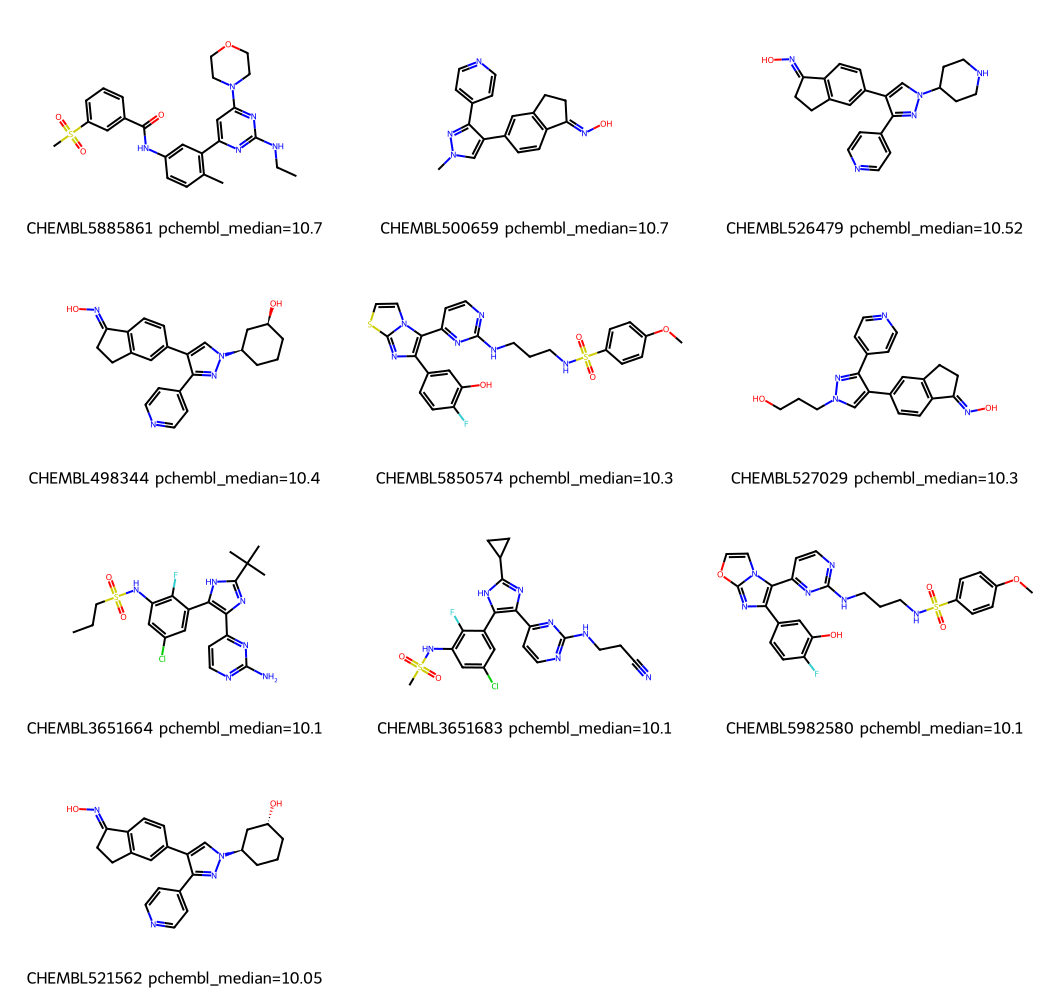

In [6]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

top10 = df.sort_values("pchembl_median", ascending=False).head(10)
mols = [Chem.MolFromSmiles(smi) for smi in top10["smiles"]]
legends = [
    f"{cid} pchembl_median={v}"
    for cid, v in zip(top10["parent_chembl_id"], top10["pchembl_median"])
]
MolsToGridImage(mols, molsPerRow=3, subImgSize=(350, 250), legends=legends)

## RCSB PDB structures for thrombin (UniProt entry name lookup)

`chem.rcsb.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` (ChEMBL target id, UniProt accession, or
UniProt entry name). It resolves the id to a UniProt accession, finds every
PDB entry annotated with that accession via the RCSB Search API, optionally
filters by resolution (entries without one, e.g. NMR structures, are dropped
whenever a threshold is given), and downloads each entry's structure file(s).
Files already present in `outdir` are left alone, so re-running only fetches
what's missing.

In [7]:
from chem import rcsb

n = rcsb.download_structures(
    "THRB_HUMAN",
    resolution_thres=1.5,
    filetype="pdb",
    outdir="data",
)
n

download_structures(id='THRB_HUMAN', resolution_thres=1.5, outdir='data', filetype='pdb')
downloading structures to data: 100%|█████████████████████████████████████████████████████████████████| 66/66 [00:00<00:00, 34772.52entry/s]
wrote 66 structures to data


66

### View one of the downloaded structures

In [10]:
import os

import py3Dmol

pdb_files = sorted(f for f in os.listdir("data") if f.endswith(".pdb"))
print(len(pdb_files), "structures downloaded, e.g.", pdb_files[:n])

with open(os.path.join("data", pdb_files[0])) as f:
    view = py3Dmol.view(width=800, height=800)
    view.addModel(f.read(), "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
view.show()

66 structures downloaded, e.g. ['1C5L.pdb', '1C5N.pdb', '1H8D.pdb', '2BVR.pdb', '2BVS.pdb', '2CF8.pdb', '2CN0.pdb', '2UUF.pdb', '2UUJ.pdb', '2UUK.pdb', '2ZFF.pdb', '3D49.pdb', '3P17.pdb', '3QX5.pdb', '3RM0.pdb', '3RM2.pdb', '3RMO.pdb', '3SI4.pdb', '3SV2.pdb', '3T5F.pdb', '3U8O.pdb', '3U8R.pdb', '3U98.pdb', '3UWJ.pdb', '3VXE.pdb', '4UD9.pdb', '4UDW.pdb', '4UE7.pdb', '4UEH.pdb', '4UFD.pdb', '4YES.pdb', '5A2M.pdb', '5AF9.pdb', '5AFY.pdb', '5AHG.pdb', '5JFD.pdb', '5JZY.pdb', '5LCE.pdb', '5LPD.pdb', '5MJT.pdb', '5MM6.pdb', '5NHU.pdb', '6FJT.pdb', '6GBW.pdb', '6I51.pdb', '6ROT.pdb', '6T3M.pdb', '6T3Q.pdb', '6T4A.pdb', '6T52.pdb', '6T53.pdb', '6T55.pdb', '6T56.pdb', '6TKG.pdb', '6TKL.pdb', '6Y02.pdb', '6Y9H.pdb', '6YB6.pdb', '6YHG.pdb', '6YHJ.pdb', '6YMP.pdb', '6YN3.pdb', '6YQV.pdb', '6YSJ.pdb', '6YSX.pdb', '7AC9.pdb']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## AlphaFold DB predicted structure for thrombin (UniProt entry name lookup)

`chem.alphafold.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` and `chem.rcsb.download_structures`. It
resolves the id to a UniProt accession and downloads every AlphaFold DB
prediction entry for it (usually one, but very large proteins may be split
into fragments, and some targets without an official prediction have
community-submitted alternatives instead), optionally filtered by a minimum
average pLDDT confidence (`plddt_thres`, 0-100). As with `chem.rcsb`, files
already present in `outdir` are left alone.

In [11]:
from chem import alphafold

n = alphafold.download_structures(
    "THRB_HUMAN",
    outdir="af_data",
    filetype="pdb",
)
n

download_structures(id='THRB_HUMAN', plddt_thres=None, outdir='af_data', filetype='pdb')
downloading structures to af_data: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2824.45entry/s]
wrote 1 structures to af_data


1

### View the predicted structure, colored by pLDDT confidence

In [13]:
import os

import py3Dmol

pdb_files = sorted(f for f in os.listdir("af_data") if f.endswith(".pdb"))
print(pdb_files)

with open(os.path.join("af_data", pdb_files[0])) as f:
    view = py3Dmol.view(width=800, height=800)
    view.addModel(f.read(), "pdb")
    # AlphaFold stores per-residue pLDDT confidence in the B-factor column.
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
    view.zoomTo()
view.show()

['AF-P00734-F1.pdb']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Aligning multiple thrombin structures with chem.protein.align

`chem.protein.align` sequence-aligns and structurally superposes a set of
same-target structures (PDB/CIF, RCSB/AlphaFold freely mixed) onto a
reference, selecting each structure's primary polymer chain automatically
(the one with the most standard amino acid residues -- e.g. thrombin's
catalytic heavy chain rather than its short light chain). It writes one PDB
file per input into `outdir`, so each can be overlaid in the same viewer.

In [15]:
import glob

from chem import protein

structures = sorted(glob.glob("data/*.pdb"))[:] + glob.glob("af_data/*.pdb")
print(structures)

rmsd = protein.align(structures, outdir="aligned")
rmsd

align(structures=['data/1C5L.pdb', 'data/1C5N.pdb', 'data/1H8D.pdb', 'data/2BVR.pdb', 'data/2BVS.pdb', 'data/2CF8.pdb', 'data/2CN0.pdb', 'data/2UUF.pdb', 'data/2UUJ.pdb', 'data/2UUK.pdb', 'data/2ZFF.pdb', 'data/3D49.pdb', 'data/3P17.pdb', 'data/3QX5.pdb', 'data/3RM0.pdb', 'data/3RM2.pdb', 'data/3RMO.pdb', 'data/3SI4.pdb', 'data/3SV2.pdb', 'data/3T5F.pdb', 'data/3U8O.pdb', 'data/3U8R.pdb', 'data/3U98.pdb', 'data/3UWJ.pdb', 'data/3VXE.pdb', 'data/4UD9.pdb', 'data/4UDW.pdb', 'data/4UE7.pdb', 'data/4UEH.pdb', 'data/4UFD.pdb', 'data/4YES.pdb', 'data/5A2M.pdb', 'data/5AF9.pdb', 'data/5AFY.pdb', 'data/5AHG.pdb', 'data/5JFD.pdb', 'data/5JZY.pdb', 'data/5LCE.pdb', 'data/5LPD.pdb', 'data/5MJT.pdb', 'data/5MM6.pdb', 'data/5NHU.pdb', 'data/6FJT.pdb', 'data/6GBW.pdb', 'data/6I51.pdb', 'data/6ROT.pdb', 'data/6T3M.pdb', 'data/6T3Q.pdb', 'data/6T4A.pdb', 'data/6T52.pdb', 'data/6T53.pdb', 'data/6T55.pdb', 'data/6T56.pdb', 'data/6TKG.pdb', 'data/6TKL.pdb', 'data/6Y02.pdb', 'data/6Y9H.pdb', 'data/6YB6.pd

['data/1C5L.pdb', 'data/1C5N.pdb', 'data/1H8D.pdb', 'data/2BVR.pdb', 'data/2BVS.pdb', 'data/2CF8.pdb', 'data/2CN0.pdb', 'data/2UUF.pdb', 'data/2UUJ.pdb', 'data/2UUK.pdb', 'data/2ZFF.pdb', 'data/3D49.pdb', 'data/3P17.pdb', 'data/3QX5.pdb', 'data/3RM0.pdb', 'data/3RM2.pdb', 'data/3RMO.pdb', 'data/3SI4.pdb', 'data/3SV2.pdb', 'data/3T5F.pdb', 'data/3U8O.pdb', 'data/3U8R.pdb', 'data/3U98.pdb', 'data/3UWJ.pdb', 'data/3VXE.pdb', 'data/4UD9.pdb', 'data/4UDW.pdb', 'data/4UE7.pdb', 'data/4UEH.pdb', 'data/4UFD.pdb', 'data/4YES.pdb', 'data/5A2M.pdb', 'data/5AF9.pdb', 'data/5AFY.pdb', 'data/5AHG.pdb', 'data/5JFD.pdb', 'data/5JZY.pdb', 'data/5LCE.pdb', 'data/5LPD.pdb', 'data/5MJT.pdb', 'data/5MM6.pdb', 'data/5NHU.pdb', 'data/6FJT.pdb', 'data/6GBW.pdb', 'data/6I51.pdb', 'data/6ROT.pdb', 'data/6T3M.pdb', 'data/6T3Q.pdb', 'data/6T4A.pdb', 'data/6T52.pdb', 'data/6T53.pdb', 'data/6T55.pdb', 'data/6T56.pdb', 'data/6TKG.pdb', 'data/6TKL.pdb', 'data/6Y02.pdb', 'data/6Y9H.pdb', 'data/6YB6.pdb', 'data/6YHG.pd

aligning structures to data/1C5L.pdb: 100%|██████████████████████████████████████████████████████████| 67/67 [00:05<00:00, 11.27structure/s]


{'data/1C5L.pdb': 0.0,
 'data/1C5N.pdb': np.float64(0.2134471729513399),
 'data/1H8D.pdb': np.float64(0.3453750632743012),
 'data/2BVR.pdb': np.float64(0.4706482968788103),
 'data/2BVS.pdb': np.float64(0.3388287761934881),
 'data/2CF8.pdb': np.float64(0.34862598806831996),
 'data/2CN0.pdb': np.float64(0.3688491070228302),
 'data/2UUF.pdb': np.float64(0.45202751033684574),
 'data/2UUJ.pdb': np.float64(0.5044010242295026),
 'data/2UUK.pdb': np.float64(0.4598074543992429),
 'data/2ZFF.pdb': np.float64(0.37703863780473723),
 'data/3D49.pdb': np.float64(0.35827570050791185),
 'data/3P17.pdb': np.float64(0.3787539238733302),
 'data/3QX5.pdb': np.float64(0.4020773648546139),
 'data/3RM0.pdb': np.float64(0.3719784307515984),
 'data/3RM2.pdb': np.float64(0.3876435969629431),
 'data/3RMO.pdb': np.float64(0.38174826857453703),
 'data/3SI4.pdb': np.float64(0.35792634549596547),
 'data/3SV2.pdb': np.float64(0.3899013831350451),
 'data/3T5F.pdb': np.float64(0.39058977701559927),
 'data/3U8O.pdb': np

### Overlay the aligned structures

In [ ]:
import os

import py3Dmol

colors = ["orange", "cyan", "magenta", "yellow", "green"]
view = py3Dmol.view(width=600, height=450)
for path, color in zip(rmsd, colors):
    aligned_path = os.path.join("aligned", os.path.splitext(os.path.basename(path))[0] + ".pdb")
    with open(aligned_path) as f:
        view.addModel(f.read(), "pdb")
    view.setStyle({"model": -1}, {"cartoon": {"color": color}})
view.zoomTo()
view.show()

## Finding the ligand pocket with chem.protein.find_pocket

`chem.protein.find_pocket` runs [fpocket](https://github.com/Discngine/fpocket)
on a PDB file and picks the pocket closest to a ligand, returning fpocket's
score/druggability/volume plus the residues lining it. `4UEH.pdb` has several
non-solvent HETATM groups (a bound benzamidine-like inhibitor `BEN`, an
N-glycosylation sugar `NAG`, a modified peptide residue `TYS`), so an explicit
HET code is used here rather than relying on auto-detection picking the
largest one.

In [ ]:
pocket = protein.find_pocket("data/4UEH.pdb", ligand="BEN")
print("pocket_id:", pocket["pocket_id"])
print("score:", pocket["score"], "druggability_score:", pocket["druggability_score"])
print("volume:", pocket["volume"])
pocket["residues"]

### Highlight the pocket residues and ligand

In [ ]:
pocket_resnums = [r["resnum"] for r in pocket["residues"]]

with open("data/4UEH.pdb") as f:
    view = py3Dmol.view(width=600, height=450)
    view.addModel(f.read(), "pdb")
    view.setStyle({"cartoon": {"color": "lightgrey"}})
    view.addStyle({"resi": pocket_resnums}, {"stick": {"colorscheme": "greenCarbon"}})
    view.addStyle({"resn": "BEN"}, {"stick": {"colorscheme": "orangeCarbon"}})
    view.zoomTo({"resi": pocket_resnums})
view.show()